In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [2]:
# Генерируем данные
np.random.seed(0)
n = 300
X = np.random.randint(1, 11, size=(n, 7))
y_true = (X.mean(axis=1) > 6).astype(int)  # логика: средняя оценка > 6

# Добавляем шум: 30% точек — портим случайные признаки
noise_mask = np.random.rand(n) < 0.3
for i in np.where(noise_mask)[0]:
    random_feat = np.random.randint(0, 7)
    X[i, random_feat] = np.random.randint(1, 11)  # случайный сбой

# Сравнение метрик
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

euclid = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

score_e = cross_val_score(euclid, X, y_true, cv=5).mean()
score_m = cross_val_score(manhattan, X, y_true, cv=5).mean()

print(f"Евклид: {score_e:.3f}")
print(f"Манхэттен: {score_m:.3f}")


Евклид: 0.843
Манхэттен: 0.850


1.0
1.0408163265306123
1.0816326530612246
1.1224489795918366
1.163265306122449
1.2040816326530612
1.2448979591836735
1.2857142857142856
1.3265306122448979
1.3673469387755102
1.4081632653061225
1.4489795918367347
1.489795918367347
1.530612244897959
1.5714285714285714
1.6122448979591835
1.6530612244897958
1.693877551020408
1.7346938775510203
1.7755102040816326
1.816326530612245
1.8571428571428572
1.8979591836734693
1.9387755102040816
1.9795918367346939
2.020408163265306
2.061224489795918
2.1020408163265305
2.142857142857143
2.183673469387755
2.224489795918367
2.2653061224489797
2.3061224489795915
2.3469387755102042
2.387755102040816
2.4285714285714284
2.4693877551020407
2.510204081632653
2.5510204081632653
2.591836734693877
2.63265306122449
2.6734693877551017
2.7142857142857144
2.7551020408163263
2.7959183673469385
2.836734693877551
2.877551020408163
2.9183673469387754
2.9591836734693877
3.0


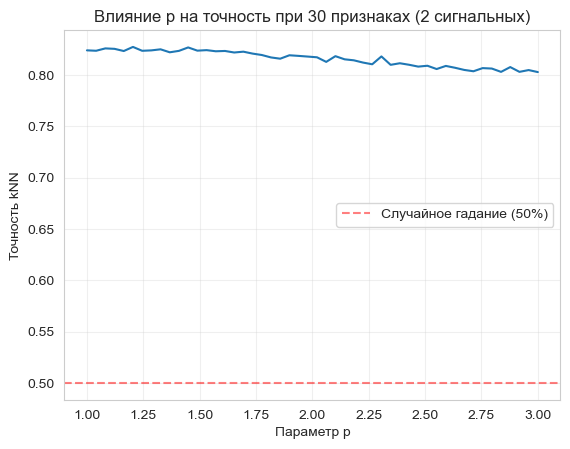

In [3]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Данные: 30 признаков, 2 сигнальных ---
np.random.seed(42)
n = 2000
X = np.random.randn(n, 30)

# Сигнальные признаки: класс 0 — центр, класс 1 — кольцо
r = np.random.choice([0, 1], size=n)
X[:, 0] = np.random.randn(n) + 2*r      # признак 1
X[:, 1] = np.random.randn(n) + 2*r      # признак 2
y = r

# Шумовые признаки оставляем случайными

# --- Стандартизация ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Эксперимент: разные p ---
p_values = np.linspace(1, 3, 50)
accuracies = []

for p in p_values:
    print(p) 
    knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=p)
    scores = []
    for _ in range(50):  # усредняем по 10 случайным разбиениям
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)
        knn.fit(X_train, y_train)
        scores.append(knn.score(X_test, y_test))
    accuracies.append(np.mean(scores))

# --- Визуализация ---
import matplotlib.pyplot as plt
plt.plot(p_values, accuracies, )
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Случайное гадание (50%)')
plt.xlabel('Параметр p')
plt.ylabel('Точность kNN')
plt.title('Влияние p на точность при 30 признаках (2 сигнальных)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [3]:
df = pd.read_csv('data/metal.csv')
df

,carbon_pct,manganese_pct,silicon_pct,sulfur_pct,phosphorus_pct,chromium_pct,nickel_pct,copper_pct,aluminum_pct,vanadium_pct,...,length_mm,temp_finish_rolling,temp_coiling,cooling_rate,tension_rolling,rolling_speed,elongation_pct,impact_strength_m40,yield_ratio,category
0,0.239705,0.202692,0.335947,0.007354,0.011625,-0.015151,0.034040,0.039825,0.042912,-0.004543,...,11123.637762,799.687163,578.737531,26.528643,26.764683,5.753519,18.212057,77.742237,0.715578,1
1,0.186847,1.136255,0.252721,0.015648,0.013660,0.111192,0.025215,0.015033,0.019995,0.019765,...,11272.258403,854.405896,638.033893,36.575280,33.311833,6.505862,28.413570,81.864543,0.716785,1
2,0.188297,0.914128,0.291510,0.011353,0.003447,0.122565,0.014973,0.011858,0.059439,0.009908,...,8652.204143,845.160618,628.529553,31.431585,16.416531,3.301266,22.379195,72.074793,0.727252,1
3,0.156488,1.055984,0.368557,0.009781,0.016166,0.162336,0.076119,0.019480,0.068086,0.005591,...,11657.234651,838.702334,563.843957,38.734102,22.746904,7.014372,23.526045,70.253183,0.600036,1
4,0.210759,1.038770,0.245114,0.007906,0.011508,0.085846,0.050128,0.010927,0.043558,-0.000133,...,10940.739775,869.394939,600.136570,41.111440,27.147025,9.640601,15.501607,57.191503,0.833878,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.161988,0.682743,0.226461,0.005880,0.023689,-0.036098,0.029234,0.027590,0.051258,0.012610,...,12821.390628,839.275215,510.305231,17.452111,24.298133,6.955740,14.179599,47.262108,0.707360,0
996,0.186954,1.113733,0.239429,0.015163,0.010188,-0.023060,0.000467,0.034956,0.032660,0.019351,...,11287.575100,846.725842,571.310027,32.914289,20.359341,5.660498,18.034580,62.077519,0.702616,0
997,0.169376,1.019220,0.211936,0.014974,0.007871,0.203252,0.035919,0.026054,0.037007,0.012107,...,9574.569848,818.023777,637.867447,18.148191,19.382904,6.641546,33.615347,85.193465,0.749081,1
998,0.172609,1.555615,0.305669,0.007548,0.010369,0.097637,0.033009,0.005801,0.043588,0.003958,...,13638.842414,870.940048,589.678216,16.107501,29.829158,5.083739,15.250094,49.979458,0.609822,0


1.0
1.25
1.5
1.75
2.0
2.25
2.5
2.75


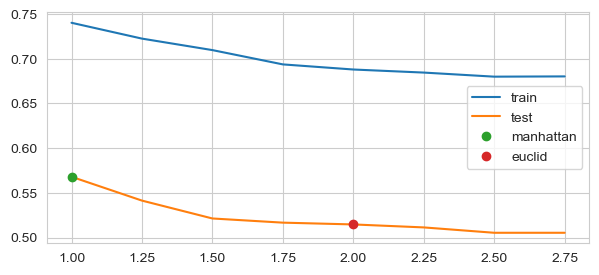

Сор Манхэттена: 0.568
Скор Евклида: 0.5147
Прирост скора: 0.0533


In [5]:
X = df.drop(columns = ['category'])
y = df['category']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# X_scaled = X


p_list = np.arange(1, 3, 0.25)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

p_Ma = 0
Ma = 0
p_Eu = 0
Eu = 0

for p in p_list:
    print(p) 

    horisontal_ax.append(p)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(5):

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=p)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

    if round(p, 1) == 1.0:
        
        Ma = np.mean(np.array(accuracy_test_list).mean())
        p_Ma = p
    
    if round(p, 1) == 2.0:
        Eu = np.mean(np.array(accuracy_test_list).mean())
        p_Eu = p

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(p_Ma, Ma, 'o', label = 'manhattan')
plt.plot(p_Eu, Eu, 'o', label='euclid')
plt.legend()
plt.show()

print('Сор Манхэттена:', round(Ma, 4))
print('Скор Евклида:', round(Eu, 4))
print('Прирост скора:', round(Ma-Eu, 4))

In [6]:
p_Ma

1.0

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


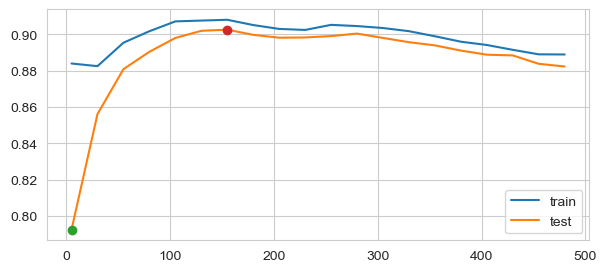

Дефолтный скор: 0.7923
Максимальный скор: 0.9027 при k = 155
Прирост скора: 0.1103


In [7]:
X = df.drop(columns = ['category'])
y = df['category']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(50*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(100):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k, metric='manhattan')
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))